Step 1 — Load & Explore Data

In [40]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [41]:
df=pd.read_csv(r"C:\Users\myjyu\Downloads\archive (6)\IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [43]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [44]:
df.duplicated().sum()

np.int64(418)

In [45]:
df.count()

review       50000
sentiment    50000
dtype: int64

In [46]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [47]:
df.count()

review       50000
sentiment    50000
dtype: int64

In [48]:
df["sentiment_Value"]=df["sentiment"].apply(lambda x: 1 if x=="positive" else 0)
df.head()
df.sentiment_Value.value_counts()

sentiment_Value
1    25000
0    25000
Name: count, dtype: int64

In [49]:
df['review_length'] = df['review'].apply(len)

In [50]:
df

,review,sentiment,sentiment_Value,review_length
0,One of the other reviewers has mentioned that ...,positive,1,1761
1,A wonderful little production. <br /><br />The...,positive,1,998
2,I thought this was a wonderful way to spend ti...,positive,1,926
3,Basically there's a family where a little boy ...,negative,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,1317
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,1,1008
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,0,642
49997,I am a Catholic taught in parochial elementary...,negative,0,1280
49998,I'm going to have to disagree with the previou...,negative,0,1234


C:\Users\myjyu\AppData\Local\Temp\ipykernel_23816\313418025.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['sentiment_Value'].value_counts().index, y=df['sentiment_Value'].value_counts().values, palette=['skyblue', 'salmon'])


([<matplotlib.axis.XTick at 0x2d2a80eff50>,
 [Text(0, 0, 'Negative'), Text(1, 0, 'Positive')])

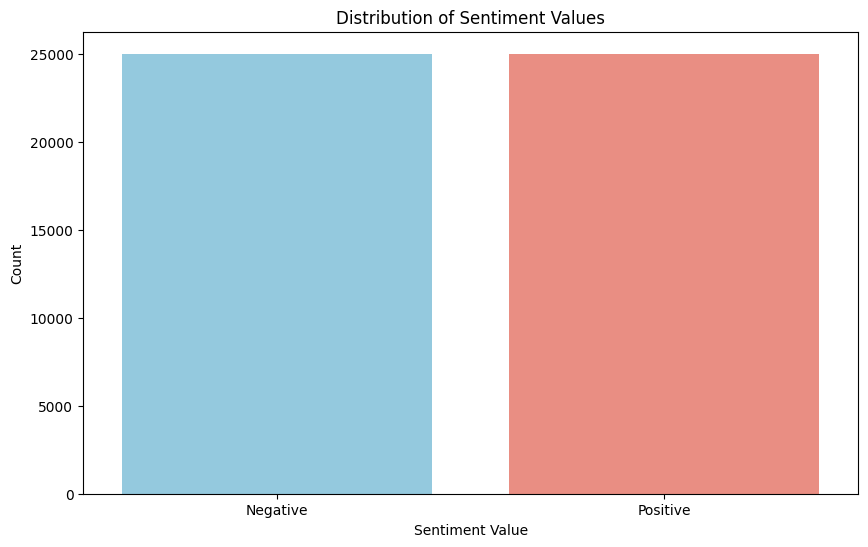

In [51]:
plt.figure(figsize=(10,6))  
sns.barplot(x=df['sentiment_Value'].value_counts().index, y=df['sentiment_Value'].value_counts().values, palette=['skyblue', 'salmon'])
plt.title('Distribution of Sentiment Values')
plt.xlabel('Sentiment Value')
plt.ylabel('Count')
plt.xticks([0, 1], ['Negative', 'Positive'])

Text(0, 0.5, 'Frequency')

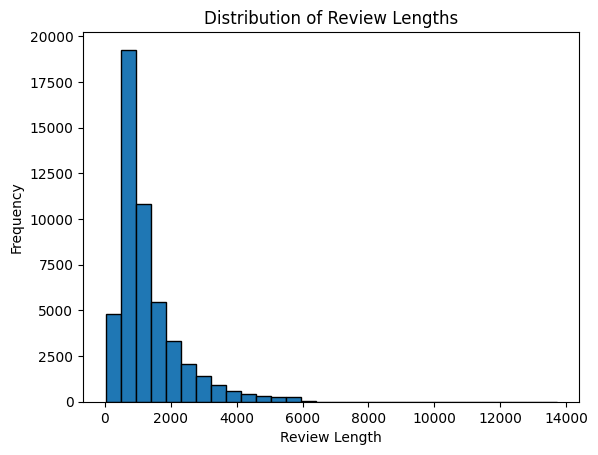

In [52]:
plt.hist(df['review_length'], bins=30, edgecolor='black')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

([<matplotlib.patches.Wedge at 0x2d2a884f650>,
 [Text(-1.0999999999999959, -9.616505800409723e-08, 'positive'),
  Text(1.0999999999999832, 1.9233011600819372e-07, 'negative')],
 [Text(-0.5999999999999978, -5.2453668002234845e-08, '50.0%'),
  Text(0.5999999999999908, 1.0490733600446929e-07, '50.0%')])

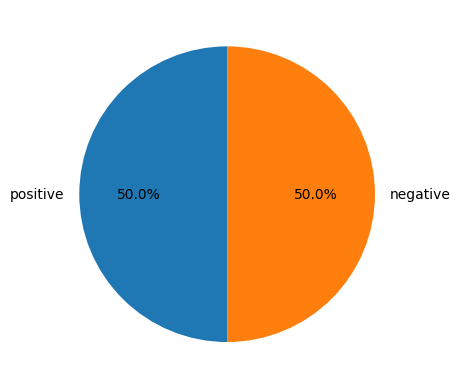

In [53]:
labels = ['positive', 'negative']
plt.pie(df['sentiment_Value'].value_counts(), labels=labels,autopct='%1.1f%%',shadow=False, startangle=90)

Step 2 — Baseline Model (TF-IDF + Logistic Regression)

In [54]:
tfidf=TfidfVectorizer(max_features=5000)
x=tfidf.fit_transform(df['review'])
y=df['sentiment_Value']

In [55]:
x.shape

(50000, 5000)

In [56]:

y.shape

(50000,)

In [57]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [58]:
y_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(10000,))

Step 3 — HuggingFace BERT Pipeline

In [59]:
from transformers import pipeline

In [60]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1896.51it/s]


In [61]:
sample = df['review'].head(500).tolist()
results = classifier(sample, truncation=True, max_length=512)

In [62]:
sample

["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the f

In [63]:
results

[{'label': 'NEGATIVE', 'score': 0.5121214389801025},
 {'label': 'POSITIVE', 'score': 0.9993765950202942},
 {'label': 'POSITIVE', 'score': 0.9991896748542786},
 {'label': 'NEGATIVE', 'score': 0.9991722106933594},
 {'label': 'POSITIVE', 'score': 0.9988238215446472},
 {'label': 'POSITIVE', 'score': 0.9997684359550476},
 {'label': 'POSITIVE', 'score': 0.9160271286964417},
 {'label': 'NEGATIVE', 'score': 0.9996374845504761},
 {'label': 'NEGATIVE', 'score': 0.9997221827507019},
 {'label': 'POSITIVE', 'score': 0.9997014403343201},
 {'label': 'NEGATIVE', 'score': 0.9986605644226074},
 {'label': 'NEGATIVE', 'score': 0.6564950346946716},
 {'label': 'NEGATIVE', 'score': 0.991620659828186},
 {'label': 'NEGATIVE', 'score': 0.9988740086555481},
 {'label': 'POSITIVE', 'score': 0.9995445609092712},
 {'label': 'NEGATIVE', 'score': 0.9997207522392273},
 {'label': 'NEGATIVE', 'score': 0.8964524865150452},
 {'label': 'NEGATIVE', 'score': 0.999383807182312},
 {'label': 'NEGATIVE', 'score': 0.99688631296157

In [64]:
df_sample = df.head(500).copy()
df_sample['hf_label'] = [r['label'] for r in results]
df_sample['hf_score'] = [r['score'] for r in results]
df_sample.head()

,review,sentiment,sentiment_Value,review_length,hf_label,hf_score
0,One of the other reviewers has mentioned that ...,positive,1,1761,NEGATIVE,0.512121
1,A wonderful little production. <br /><br />The...,positive,1,998,POSITIVE,0.999377
2,I thought this was a wonderful way to spend ti...,positive,1,926,POSITIVE,0.999190
3,Basically there's a family where a little boy ...,negative,0,748,NEGATIVE,0.999172
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,1317,POSITIVE,0.998824


Step 4 — Evaluation & Comparison

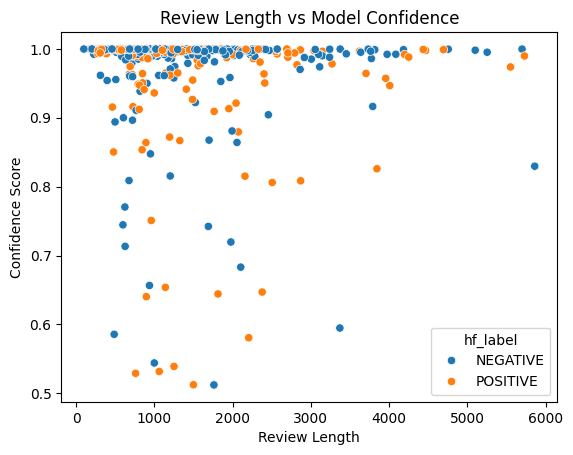

In [65]:
sns.scatterplot(data=df_sample, x='review_length', y='hf_score',hue='hf_label')
plt.xlabel('Review Length')
plt.ylabel('Confidence Score')
plt.title('Review Length vs Model Confidence')
plt.show()

In [66]:
df_sample['sentiment_upper'] = df_sample['sentiment'].str.upper()
correct = (df_sample['hf_label'] == df_sample['sentiment_upper']).sum()
print(f"HuggingFace Accuracy: {correct/500:.2%}")

HuggingFace Accuracy: 90.40%


In [67]:
df_sample

,review,sentiment,sentiment_Value,review_length,hf_label,hf_score,sentiment_upper
0,One of the other reviewers has mentioned that ...,positive,1,1761,NEGATIVE,0.512121,POSITIVE
1,A wonderful little production. <br /><br />The...,positive,1,998,POSITIVE,0.999377,POSITIVE
2,I thought this was a wonderful way to spend ti...,positive,1,926,POSITIVE,0.999190,POSITIVE
3,Basically there's a family where a little boy ...,negative,0,748,NEGATIVE,0.999172,NEGATIVE
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,1317,POSITIVE,0.998824,POSITIVE
...,...,...,...,...,...,...,...
495,"""American Nightmare"" is officially tied, in my...",negative,0,1298,NEGATIVE,0.999143,NEGATIVE
496,"First off, I have to say that I loved the book...",negative,0,880,NEGATIVE,0.999344,NEGATIVE
497,This movie was extremely boring. I only laughe...,negative,0,792,NEGATIVE,0.999558,NEGATIVE
498,I was disgusted by this movie. No it wasn't be...,negative,0,1195,POSITIVE,0.871945,NEGATIVE


In [68]:
correct

np.int64(452)

C:\Users\myjyu\AppData\Local\Temp\ipykernel_23816\1620412139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette=['lightblue','lightcoral'], width=0.4, edgecolor='black')


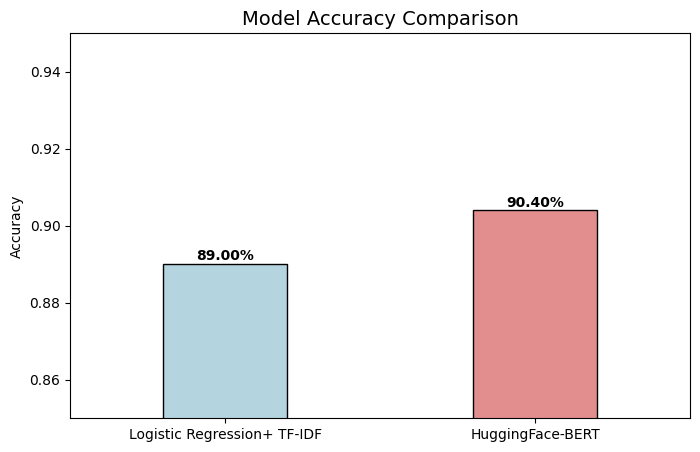

In [69]:
models = ['Logistic Regression+ TF-IDF', 'HuggingFace-BERT']
scores = [0.89, 0.9040]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=scores, palette=['lightblue','lightcoral'], width=0.4, edgecolor='black')
plt.ylim(0.85, 0.95)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
for i, v in enumerate(scores):plt.text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')


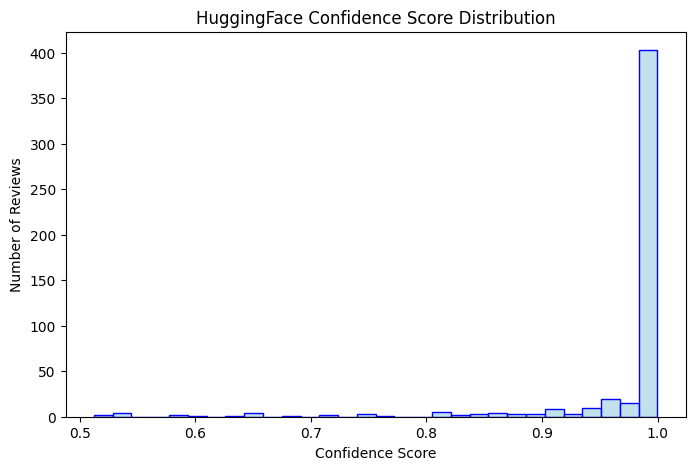

In [70]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sample['hf_score'], bins=30, color='lightblue', edgecolor='blue')
plt.title('HuggingFace Confidence Score Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Reviews')
plt.show()

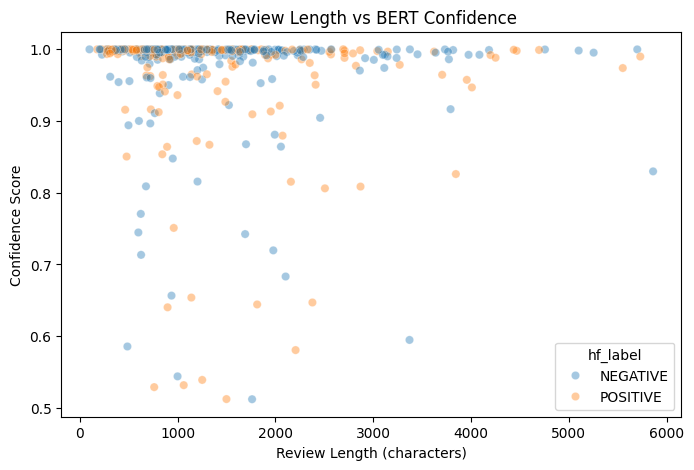

In [71]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_sample, x='review_length', y='hf_score', alpha=0.4,hue='hf_label')
plt.title('Review Length vs BERT Confidence')
plt.xlabel('Review Length (characters)')
plt.ylabel('Confidence Score')

plt.show()

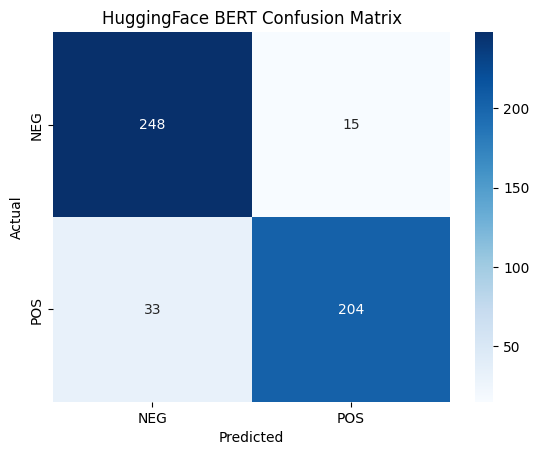

In [72]:
cm = confusion_matrix(df_sample['sentiment_upper'], df_sample['hf_label'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['NEG', 'POS'],yticklabels=['NEG', 'POS'])
plt.title('HuggingFace BERT Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()